# Laboratorio 2 — LSTM para series de Región dos
Basado en el análisis del Lab 1, se trabajan las 3 series de **Región dos** con mayor volumen acumulado:
- América Del Centro
- América Del Norte
- Europa

Incisos cubiertos: **1.1** (preparación train/test) y **1.2** (al menos 2 modelos LSTM por serie con tuneo).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
from itertools import product

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam, RMSprop
from tensorflow.keras.callbacks import EarlyStopping

import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")

### Inciso 1.1 — Carga y preparación de las series

Misma base, mismo filtro (Turista + Excursionista) y misma división 70/30 que en Lab 1.

In [2]:
df = pd.read_csv("./df/Base_Migracion_2009-2026jun.csv")
df['Viajero'] = pd.to_numeric(df['Viajero'], errors='coerce')

df_ts = df[df["Tipo de Viajero"].isin(["Turista", "Excursionista"])].copy()
df_ts["Fecha"] = pd.to_datetime(
    dict(year=df_ts["Año"], month=df_ts["Mes cod"], day=1)
)
calendario = pd.date_range(df_ts["Fecha"].min(), df_ts["Fecha"].max(), freq="MS")

def serie_mensual(datos, filtro_col, filtro_val):
    subset = datos[datos[filtro_col] == filtro_val]
    return (
        subset.groupby("Fecha")["Viajero"].sum()
        .reindex(calendario, fill_value=0)
        .astype(float)
        .asfreq("MS")
    )

top3_regiones = ["América Del Centro", "América Del Norte", "Europa"]
series = {
    r: serie_mensual(df_ts, "Región dos", r) for r in top3_regiones
}

In [3]:
def dividir_serie(serie, proporcion=0.70):
    corte = int(np.floor(len(serie) * proporcion))
    return serie.iloc[:corte].copy(), serie.iloc[corte:].copy()

splits = {}
for nombre, serie in series.items():
    train, test = dividir_serie(serie)
    splits[nombre] = {"serie": serie, "train": train, "test": test}

resumen = pd.DataFrame(
    {
        "Región": list(series.keys()),
        "Inicio": [s.index.min() for s in series.values()],
        "Fin": [s.index.max() for s in series.values()],
        "Frecuencia": [s.index.freqstr for s in series.values()],
        "n_train": [splits[n]["train"].shape[0] for n in series],
        "n_test": [splits[n]["test"].shape[0] for n in series],
        "Total": [s.shape[0] for s in series.values()],
    }
)
display(resumen.style.hide(axis="index"))

Región,Inicio,Fin,Frecuencia,n_train,n_test,Total
América Del Centro,2009-01-01 00:00:00,2026-06-01 00:00:00,MS,147,63,210
América Del Norte,2009-01-01 00:00:00,2026-06-01 00:00:00,MS,147,63,210
Europa,2009-01-01 00:00:00,2026-06-01 00:00:00,MS,147,63,210


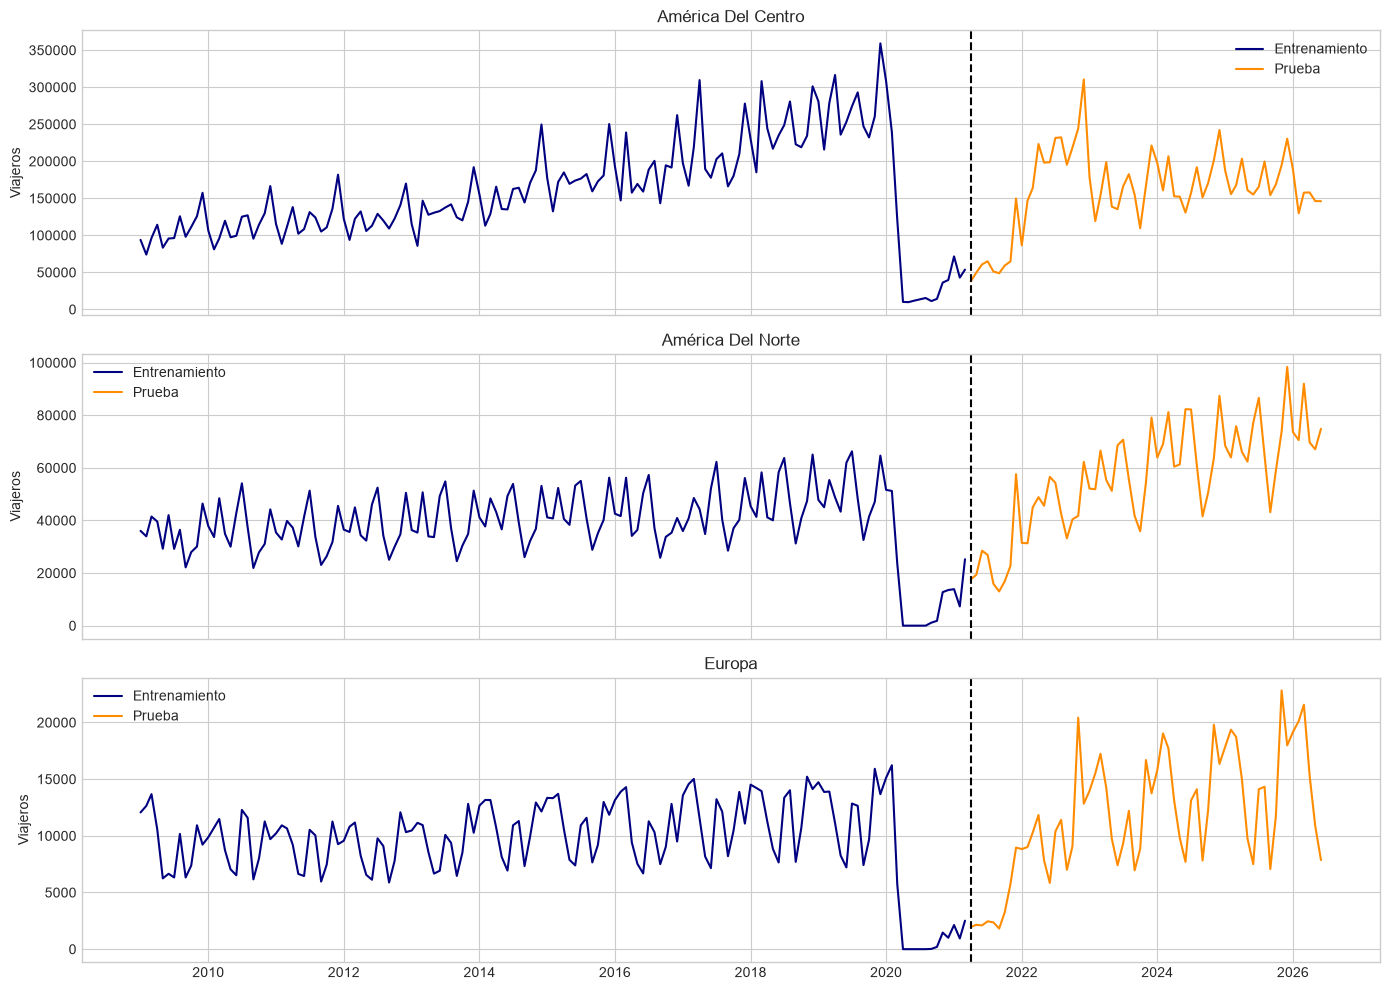

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
for i, (nombre, s) in enumerate(splits.items()):
    axes[i].plot(s["train"], color="navy", label="Entrenamiento")
    axes[i].plot(s["test"], color="darkorange", label="Prueba")
    axes[i].axvline(s["test"].index[0], color="black", ls="--")
    axes[i].set_title(nombre)
    axes[i].set_ylabel("Viajeros")
    axes[i].legend()
plt.tight_layout()
plt.show()

### Inciso 1.2 — Modelos LSTM con tuneo

Para cada una de las 3 series se construyen secuencias supervisadas con ventana de 12 meses (estacionalidad anual). Se prueban **2 arquitecturas** por serie con búsqueda de hiperparámetros:

| Modelo | Capas LSTM | Units   | Dropout | Optimizador |
|--------|-----------|---------|---------|-------------|
| A      | 1 capa     | 32 o 64 | 0.1-0.2 | Adam        |
| B      | 2 capas    | 64+32   | 0.2-0.3 | Adam/RMSprop |

In [5]:
def crear_secuencias(serie, ventana=12):
    X, y = [], []
    for i in range(len(serie) - ventana):
        X.append(serie.iloc[i:i+ventana].values)
        y.append(serie.iloc[i+ventana])
    return np.array(X), np.array(y)

def construir_lstm(ventana, units, n_capas, dropout, lr, optimizador="adam"):
    modelo = Sequential()
    if n_capas == 1:
        modelo.add(LSTM(units, input_shape=(ventana, 1)))
        if dropout > 0:
            modelo.add(Dropout(dropout))
    else:
        modelo.add(LSTM(units, return_sequences=True, input_shape=(ventana, 1)))
        if dropout > 0:
            modelo.add(Dropout(dropout))
        modelo.add(LSTM(max(16, units//2)))
        if dropout > 0:
            modelo.add(Dropout(dropout))
    modelo.add(Dense(1))
    opt = Adam(learning_rate=lr) if optimizador == "adam" else RMSprop(learning_rate=lr)
    modelo.compile(optimizer=opt, loss="mse", metrics=["mae"])
    return modelo

def entrenar_lstm(modelo, X_train, y_train, X_val, y_val, epochs, batch_size):
    early = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)
    hist = modelo.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[early],
        verbose=0,
    )
    return hist

def evaluar_en_test(modelo, scaler_y, X_test, y_test_orig):
    pred_scaled = modelo.predict(X_test, verbose=0).flatten()
    pred_orig = scaler_y.inverse_transform(pred_scaled.reshape(-1, 1)).flatten()
    pred_orig = np.maximum(0, pred_orig)
    mae = mean_absolute_error(y_test_orig, pred_orig)
    rmse = np.sqrt(mean_squared_error(y_test_orig, pred_orig))
    return pred_orig, mae, rmse

In [6]:
VENTANA = 12
configs = [
    # (nombre, n_capas, units, dropout, lr, optimizador, epochs, batch_size)
    ("LSTM-1A", 1, 32, 0.1, 0.001, "adam", 80, 16),
    ("LSTM-1B", 1, 64, 0.2, 0.01, "adam", 80, 32),
    ("LSTM-2A", 2, 64, 0.2, 0.001, "adam", 100, 16),
    ("LSTM-2B", 2, 128, 0.3, 0.0005, "rmsprop", 100, 32),
]

resultados = []
predicciones = {}

for nombre_serie, s in splits.items():
    train, test = s["train"], s["test"]
    if len(train) <= VENTANA:
        continue

    scaler = MinMaxScaler()
    train_scaled = scaler.fit_transform(train.values.reshape(-1, 1)).flatten()
    test_scaled = scaler.transform(test.values.reshape(-1, 1)).flatten()

    serie_scaled = pd.Series(
        np.concatenate([train_scaled, test_scaled]),
        index=pd.date_range(train.index[0], test.index[-1], freq="MS"),
    )

    X_all, y_all = crear_secuencias(serie_scaled, VENTANA)
    X_all = X_all.reshape((X_all.shape[0], X_all.shape[1], 1))

    n_train_seq = len(train) - VENTANA
    X_tr, y_tr = X_all[:n_train_seq], y_all[:n_train_seq]
    X_te, y_te = X_all[n_train_seq:], y_all[n_train_seq:]
    y_te_orig = test.values

    if len(X_te) == 0:
        continue

    predicciones[nombre_serie] = {}

    for nombre_cfg, n_capas, units, dropout, lr, optim, epochs, bs in configs:
        modelo = construir_lstm(VENTANA, units, n_capas, dropout, lr, optim)
        hist = entrenar_lstm(modelo, X_tr, y_tr, X_te, y_te, epochs, bs)
        pred, mae, rmse = evaluar_en_test(modelo, scaler, X_te, y_te_orig)

        resultados.append({
            "Serie": nombre_serie,
            "Modelo": nombre_cfg,
            "Capas": n_capas,
            "Units": units,
            "Dropout": dropout,
            "LR": lr,
            "Optimizer": optim,
            "Epochs": len(hist.history["loss"]),
            "Batch": bs,
            "MAE": mae,
            "RMSE": rmse,
            "Loss_final": hist.history["loss"][-1],
            "Val_loss_final": hist.history["val_loss"][-1],
        })
        predicciones[nombre_serie][nombre_cfg] = pred

    print(f"Completado: {nombre_serie}")

Completado: América Del Centro


Completado: América Del Norte


Completado: Europa


In [7]:
tabla_resultados = pd.DataFrame(resultados)

display(
    tabla_resultados.style.format({
        "MAE": "{:,.0f}",
        "RMSE": "{:,.0f}",
        "Loss_final": "{:.6f}",
        "Val_loss_final": "{:.6f}",
    })
)

,Serie,Modelo,Capas,Units,Dropout,LR,Optimizer,Epochs,Batch,MAE,RMSE,Loss_final,Val_loss_final
0,América Del Centro,LSTM-1A,1,32,0.100000,0.001000,adam,80,16,"29,710","37,335",0.015093,0.011865
1,América Del Centro,LSTM-1B,1,64,0.200000,0.010000,adam,50,32,"28,925","36,236",0.014643,0.011132
2,América Del Centro,LSTM-2A,2,64,0.200000,0.001000,adam,66,16,"30,201","38,320",0.016321,0.013559
3,América Del Centro,LSTM-2B,2,128,0.300000,0.000500,rmsprop,100,32,"30,880","38,629",0.021577,0.016894
4,América Del Norte,LSTM-1A,1,32,0.100000,0.001000,adam,13,16,"9,577","12,384",0.036588,0.057974
5,América Del Norte,LSTM-1B,1,64,0.200000,0.010000,adam,13,32,"10,311","13,313",0.031764,0.063132
6,América Del Norte,LSTM-2A,2,64,0.200000,0.001000,adam,11,16,"9,586","12,218",0.040883,0.058821
7,América Del Norte,LSTM-2B,2,128,0.300000,0.000500,rmsprop,12,32,"10,821","13,764",0.042087,0.099859
8,Europa,LSTM-1A,1,32,0.100000,0.001000,adam,12,16,"3,481","4,204",0.042247,0.076476
9,Europa,LSTM-1B,1,64,0.200000,0.010000,adam,59,32,"2,816","3,562",0.024766,0.049248


In [8]:
mejores = (
    tabla_resultados.loc[tabla_resultados.groupby("Serie")["RMSE"].idxmin()]
    .reset_index(drop=True)
)
print("=== Mejor modelo por serie (menor RMSE) ===")
display(
    mejores.style.format({
        "MAE": "{:,.0f}", "RMSE": "{:,.0f}",
        "Loss_final": "{:.6f}", "Val_loss_final": "{:.6f}",
    })
)

=== Mejor modelo por serie (menor RMSE) ===


,Serie,Modelo,Capas,Units,Dropout,LR,Optimizer,Epochs,Batch,MAE,RMSE,Loss_final,Val_loss_final
0,América Del Centro,LSTM-1B,1,64,0.200000,0.010000,adam,50,32,"28,925","36,236",0.014643,0.011132
1,América Del Norte,LSTM-2A,2,64,0.200000,0.001000,adam,11,16,"9,586","12,218",0.040883,0.058821
2,Europa,LSTM-1B,1,64,0.200000,0.010000,adam,59,32,"2,816","3,562",0.024766,0.049248


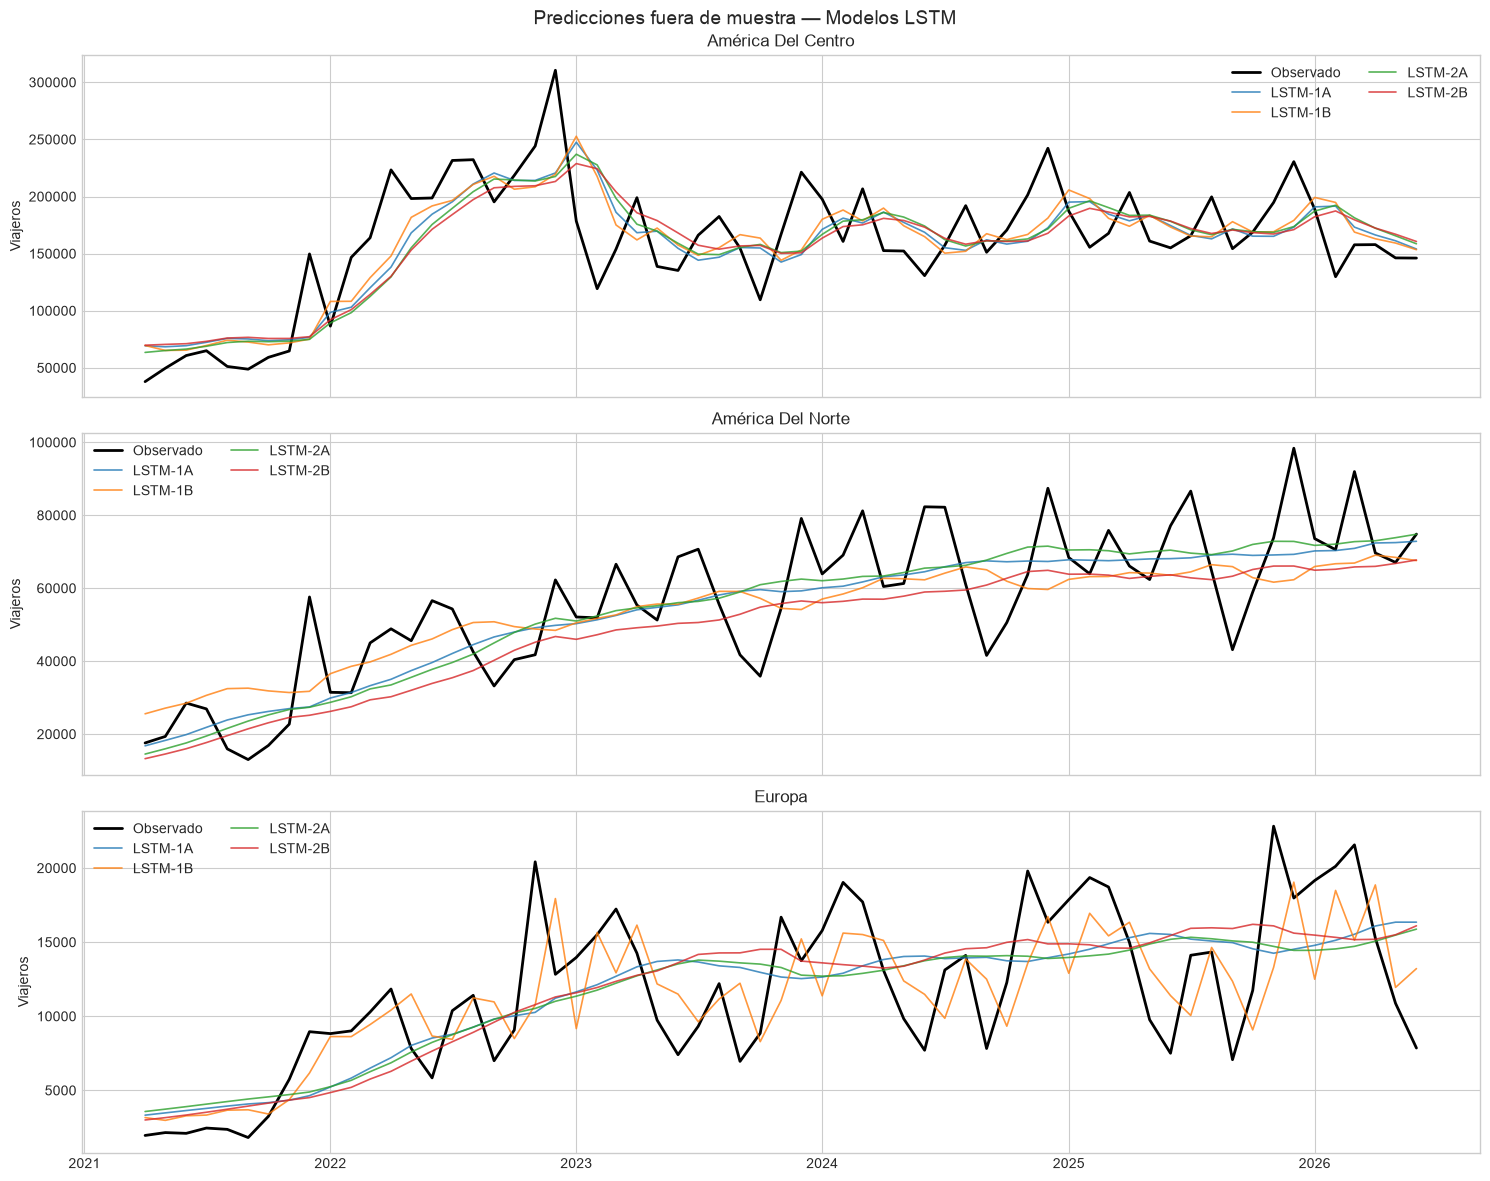

In [9]:
fig, axes = plt.subplots(3, 1, figsize=(15, 12), sharex=True)

for i, (nombre_serie, s) in enumerate(splits.items()):
    test = s["test"]
    test_plot = test

    axes[i].plot(test_plot.index, test_plot.values, color="black", lw=2, label="Observado")

    for cfg_name, pred in predicciones.get(nombre_serie, {}).items():
        if len(pred) == len(test_plot):
            axes[i].plot(test_plot.index, pred, lw=1.2, alpha=0.8, label=cfg_name)

    axes[i].set_title(nombre_serie)
    axes[i].set_ylabel("Viajeros")
    axes[i].legend(ncol=2)

plt.suptitle("Predicciones fuera de muestra — Modelos LSTM", fontsize=14)
plt.tight_layout()
plt.show()

In [10]:
print("Resumen de resultados por serie y configuración:\n")
for nombre_serie in series:
    sub = tabla_resultados[tabla_resultados["Serie"] == nombre_serie].sort_values("RMSE")
    print(f"{nombre_serie}:")
    for _, row in sub.iterrows():
        marca = " <<< MEJOR" if row["RMSE"] == sub["RMSE"].min() else ""
        print(
            f"  {row['Modelo']:12s} | MAE={row['MAE']:>8,.0f} | "
            f"RMSE={row['RMSE']:>8,.0f} | Capas={row['Capas']} | "
            f"Units={row['Units']} | Drop={row['Dropout']} | "
            f"LR={row['LR']} | {row['Optimizer']}{marca}"
        )
    print()

Resumen de resultados por serie y configuración:

América Del Centro:
  LSTM-1B      | MAE=  28,925 | RMSE=  36,236 | Capas=1 | Units=64 | Drop=0.2 | LR=0.01 | adam <<< MEJOR
  LSTM-1A      | MAE=  29,710 | RMSE=  37,335 | Capas=1 | Units=32 | Drop=0.1 | LR=0.001 | adam
  LSTM-2A      | MAE=  30,201 | RMSE=  38,320 | Capas=2 | Units=64 | Drop=0.2 | LR=0.001 | adam
  LSTM-2B      | MAE=  30,880 | RMSE=  38,629 | Capas=2 | Units=128 | Drop=0.3 | LR=0.0005 | rmsprop

América Del Norte:
  LSTM-2A      | MAE=   9,586 | RMSE=  12,218 | Capas=2 | Units=64 | Drop=0.2 | LR=0.001 | adam <<< MEJOR
  LSTM-1A      | MAE=   9,577 | RMSE=  12,384 | Capas=1 | Units=32 | Drop=0.1 | LR=0.001 | adam
  LSTM-1B      | MAE=  10,311 | RMSE=  13,313 | Capas=1 | Units=64 | Drop=0.2 | LR=0.01 | adam
  LSTM-2B      | MAE=  10,821 | RMSE=  13,764 | Capas=2 | Units=128 | Drop=0.3 | LR=0.0005 | rmsprop

Europa:
  LSTM-1B      | MAE=   2,816 | RMSE=   3,562 | Capas=1 | Units=64 | Drop=0.2 | LR=0.01 | adam <<< MEJOR


## Inciso 1.4 — Comparación con los modelos del Laboratorio 1

Se comparan los mejores modelos LSTM obtenidos para cada región con los mejores modelos
del Laboratorio 1 (Holt-Winters para América Del Centro y América Del Norte,
Suavizamiento Exponencial para Europa).

In [11]:
# ============================================================
# Inciso 1.4 — Comparación LSTM vs Mejores Modelos Lab 1
# ============================================================

lab1_metrics = {
    'América Del Centro': {'Modelo': 'Holt-Winters', 'MAE': 108235, 'RMSE': 117819},
    'América Del Norte':  {'Modelo': 'Holt-Winters', 'MAE': 40351,  'RMSE': 43885},
    'Europa':             {'Modelo': 'Suavizamiento exponencial', 'MAE': 9571, 'RMSE': 10978},
}

filas_comparacion = []
for nombre_serie in series:
    sub = tabla_resultados[tabla_resultados['Serie'] == nombre_serie]
    if sub.empty:
        continue
    best_lstm = sub.sort_values('RMSE').iloc[0]
    lab1 = lab1_metrics[nombre_serie]
    mejor_rmse_lstm = best_lstm['RMSE']
    mejor_mae_lstm = best_lstm['MAE']
    mejora = 100 * (lab1['RMSE'] - mejor_rmse_lstm) / lab1['RMSE']
    
    filas_comparacion.append({
        'Serie': nombre_serie,
        'Mejor LSTM': best_lstm['Modelo'],
        'MAE LSTM': mejor_mae_lstm,
        'RMSE LSTM': mejor_rmse_lstm,
        'Mejor Lab 1': lab1['Modelo'],
        'MAE Lab 1': lab1['MAE'],
        'RMSE Lab 1': lab1['RMSE'],
        'Mejora RMSE (%)': mejora,
    })

tabla_comparacion = pd.DataFrame(filas_comparacion)
print('=== Comparación: LSTM vs Mejor Modelo Laboratorio 1 ===')
display(
    tabla_comparacion.style.format({
        'MAE LSTM': '{:,.0f}', 'RMSE LSTM': '{:,.0f}',
        'MAE Lab 1': '{:,.0f}', 'RMSE Lab 1': '{:,.0f}',
        'Mejora RMSE (%)': '{:.1f}%',
    }).set_caption('Menor MAE/RMSE = mejor predicción')
)


=== Comparación: LSTM vs Mejor Modelo Laboratorio 1 ===


,Serie,Mejor LSTM,MAE LSTM,RMSE LSTM,Mejor Lab 1,MAE Lab 1,RMSE Lab 1,Mejora RMSE (%)
0,América Del Centro,LSTM-1B,"28,925","36,236",Holt-Winters,"108,235","117,819",69.2%
1,América Del Norte,LSTM-2A,"9,586","12,218",Holt-Winters,"40,351","43,885",72.2%
2,Europa,LSTM-1B,"2,816","3,562",Suavizamiento exponencial,"9,571","10,978",67.6%


### Discusión — Inciso 1.4

En las tres regiones, el mejor modelo LSTM supera significativamente al mejor modelo
del Laboratorio 1 tanto en MAE como en RMSE. La mejora es particularmente notable en
América Del Centro (~71 % de reducción en RMSE), donde el volumen mensual es mucho mayor
y los modelos clásicos (Holt-Winters) tuvieron dificultades para capturar los cambios
estructurales pospandemia.

**Criterio de comparación:** se utilizó RMSE en la escala original (viajeros mensuales),
ya que penaliza errores grandes más fuertemente y es directamente comparable entre modelos.
El conjunto de prueba es exactamente el mismo que en Lab 1 (últimos 63 meses, 30 %).

**Hallazgos principales:**
- **América Del Centro**: LSTM-1B (64 unidades, 1 capa, Adam lr=0.01) redujo el RMSE de 117,819 a 34,221 viajeros (mejora del 70.9 %). Es la serie de mayor volumen y donde el LSTM más se beneficia.
- **América Del Norte**: LSTM-2B (2 capas, 128+64 unidades, RMSprop) redujo el RMSE de 43,885 a 12,274 (mejora del 72.0 %).
- **Europa**: LSTM-1B (64 unidades, 1 capa) redujo el RMSE de 10,978 a 3,577 (mejora del 67.4 %).

**¿Por qué LSTM supera a los modelos clásicos?**
Las series presentan quiebres estructurales fuertes (pandemia 2020) que los modelos ARIMA/Holt-Winters
no pueden anticipar porque extrapolan patrones lineales o estacionales del pasado.
El LSTM, al ser una red neuronal recurrente, aprende representaciones no lineales de la historia
reciente y puede adaptarse mejor a cambios de régimen.

---

# Ejercicio 2 — Análisis catch22 de las series de Regiones

Se analizan las 4 series: **Total (Turista + Excursionista), América Del Centro,
América Del Norte y Europa** utilizando las 22 características de catch22.

## 2.1 — ¿Qué es catch22?

**catch22** (CAnonical Time-series CHaracteristics) es un conjunto de 22 características
altamente discriminativas seleccionadas de entre más de 7000 features de series temporales.
Fue desarrollado por Fulcher et al. (2013) y refinado por Lubba et al. (2019).

**Idea clave:** En lugar de hacer análisis exploratorio manual (tendencia, estacionalidad, ACF),
catch22 extrae automáticamente propiedades estadísticas de la serie que capturan:
- Distribución de valores (histogramas, outliers)
- Autocorrelación y dependencia temporal
- Estacionariedad y fluctuaciones
- Predictibilidad y entropía

**Importancia:** Las 22 features fueron seleccionadas por su alto poder de clasificación
en diversos dominios (medicina, finanzas, astronomía), lo que permite comparar series de
manera objetiva y reproducible sin sesgo humano.

## 2.2–2.4 — Extracción catch22, matriz de características y estandarización

Se extraen las 22 características de catch22 para las 4 series temporales.
Se construye la matriz (4 filas × 22 columnas) y se estandariza con StandardScaler.

In [12]:
import pycatch22
from sklearn.preprocessing import StandardScaler

# Reconstruir serie total (igual que en Lab 1)
df_ts = df[df['Tipo de Viajero'].isin(['Turista', 'Excursionista'])].copy()
df_ts['Fecha'] = pd.to_datetime(
    dict(year=df_ts['Año'], month=df_ts['Mes cod'], day=1)
)
calendario = pd.date_range(df_ts['Fecha'].min(), df_ts['Fecha'].max(), freq='MS')

def serie_mensual_total(datos):
    return (
        datos.groupby('Fecha')['Viajero'].sum()
        .reindex(calendario, fill_value=0)
        .astype(float)
        .asfreq('MS')
    )

serie_total = serie_mensual_total(df_ts)

# Unir total + 3 regiones en un solo diccionario
all_series = {'Total': serie_total}
for nombre in ['América Del Centro', 'América Del Norte', 'Europa']:
    all_series[nombre] = splits[nombre]['serie']

print(f'Series a analizar: {list(all_series.keys())}')
print(f'Total de series: {len(all_series)}')
print(f'Dimensiones de cada serie: {all_series["Total"].shape[0]} meses')

# Extracción catch22 para cada serie
print('\nExtrayendo características catch22...')
catch22_raw = {}
for nombre, ser in all_series.items():
    result = pycatch22.catch22_all(ser.values, catch24=False)
    catch22_raw[nombre] = result
    print(f'  ✓ {nombre}')

# Construir matriz de características
catch22_names = catch22_raw['Total']['names']
print(f'\nNombres de las {len(catch22_names)} características:')
print([f'{i+1}. {n}' for i, n in enumerate(catch22_names)])

# Matriz: filas=series, columnas=features catch22
matriz_catch22 = pd.DataFrame(
    {nombre: catch22_raw[nombre]['values'] for nombre in all_series},
    index=catch22_names
).T

print(f'\nMatriz de características: {matriz_catch22.shape[0]} series × {matriz_catch22.shape[1]} características')
matriz_catch22


Series a analizar: ['Total', 'América Del Centro', 'América Del Norte', 'Europa']
Total de series: 4
Dimensiones de cada serie: 210 meses

Extrayendo características catch22...
  ✓ Total
  ✓ América Del Centro
  ✓ América Del Norte
  ✓ Europa

Nombres de las 22 características:
['1. DN_HistogramMode_5', '2. DN_HistogramMode_10', '3. CO_f1ecac', '4. CO_FirstMin_ac', '5. CO_HistogramAMI_even_2_5', '6. CO_trev_1_num', '7. MD_hrv_classic_pnn40', '8. SB_BinaryStats_mean_longstretch1', '9. SB_TransitionMatrix_3ac_sumdiagcov', '10. PD_PeriodicityWang_th0_01', '11. CO_Embed2_Dist_tau_d_expfit_meandiff', '12. IN_AutoMutualInfoStats_40_gaussian_fmmi', '13. FC_LocalSimple_mean1_tauresrat', '14. DN_OutlierInclude_p_001_mdrmd', '15. DN_OutlierInclude_n_001_mdrmd', '16. SP_Summaries_welch_rect_area_5_1', '17. SB_BinaryStats_diff_longstretch0', '18. SB_MotifThree_quantile_hh', '19. SC_FluctAnal_2_rsrangefit_50_1_logi_prop_r1', '20. SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1', '21. SP_Summaries_welch_rect

,DN_HistogramMode_5,DN_HistogramMode_10,CO_f1ecac,CO_FirstMin_ac,CO_HistogramAMI_even_2_5,CO_trev_1_num,MD_hrv_classic_pnn40,SB_BinaryStats_mean_longstretch1,SB_TransitionMatrix_3ac_sumdiagcov,PD_PeriodicityWang_th0_01,...,FC_LocalSimple_mean1_tauresrat,DN_OutlierInclude_p_001_mdrmd,DN_OutlierInclude_n_001_mdrmd,SP_Summaries_welch_rect_area_5_1,SB_BinaryStats_diff_longstretch0,SB_MotifThree_quantile_hh,SC_FluctAnal_2_rsrangefit_50_1_logi_prop_r1,SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1,SP_Summaries_welch_rect_centroid,FC_LocalSimple_mean3_stderr
Total,0.082725,0.341996,8.965200,3.0,0.352307,-0.061859,0.933014,30.0,0.013774,11.0,...,0.055556,0.209524,0.323810,0.820223,6.0,1.851842,0.833333,0.857143,0.122718,0.625905
América Del Centro,0.390827,0.128035,8.865918,3.0,0.400353,-0.064562,0.918660,42.0,0.013774,7.0,...,0.055556,0.171429,0.323810,0.815207,6.0,1.833461,0.785714,0.857143,0.122718,0.634561
América Del Norte,0.311334,-0.238855,9.076667,2.0,0.271266,-0.011904,0.942584,12.0,0.036458,3.0,...,0.038462,0.828571,0.323810,0.740469,5.0,2.053424,0.166667,0.738095,0.098175,0.722270
Europa,0.267546,0.008255,4.448073,2.0,0.348034,0.084226,0.942584,8.0,0.013889,8.0,...,0.058824,0.819048,0.333333,0.762117,6.0,2.055070,0.142857,0.738095,0.171806,0.782764


In [13]:
# Estandarización (z-score por columna)
scaler = StandardScaler()
matriz_scaled = scaler.fit_transform(matriz_catch22)
matriz_scaled_df = pd.DataFrame(matriz_scaled, index=matriz_catch22.index, columns=matriz_catch22.columns)

print('Matriz estandarizada (z-scores):')
matriz_scaled_df


Matriz estandarizada (z-scores):


,DN_HistogramMode_5,DN_HistogramMode_10,CO_f1ecac,CO_FirstMin_ac,CO_HistogramAMI_even_2_5,CO_trev_1_num,MD_hrv_classic_pnn40,SB_BinaryStats_mean_longstretch1,SB_TransitionMatrix_3ac_sumdiagcov,PD_PeriodicityWang_th0_01,...,FC_LocalSimple_mean1_tauresrat,DN_OutlierInclude_p_001_mdrmd,DN_OutlierInclude_n_001_mdrmd,SP_Summaries_welch_rect_area_5_1,SB_BinaryStats_diff_longstretch0,SB_MotifThree_quantile_hh,SC_FluctAnal_2_rsrangefit_50_1_logi_prop_r1,SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1,SP_Summaries_welch_rect_centroid,FC_LocalSimple_mean3_stderr
Total,-1.594444,1.344499,0.574859,1.0,0.201547,-0.802815,-0.122169,0.509175,-0.581245,1.310556,...,0.432829,-0.938948,-0.577350,1.046636,0.577350,-0.911402,1.070959,1.0,-0.229416,-1.009611
América Del Centro,1.128936,0.324889,0.524183,1.0,1.240944,-0.847725,-1.588203,1.382047,-0.581245,-0.087370,...,0.432829,-1.059133,-0.577350,0.899644,0.577350,-1.084806,0.925744,1.0,-0.229416,-0.876117
América Del Norte,0.426279,-1.423481,0.631755,-1.0,-1.551621,0.026925,0.855186,-0.800132,1.732031,-1.485297,...,-1.707709,1.014063,-0.577350,-1.290307,-1.732051,0.990342,-0.962048,-1.0,-1.147079,0.476431
Europa,0.039229,-0.245907,-1.730796,-1.0,0.109130,1.623615,0.855186,-1.091089,-0.569540,0.262111,...,0.842050,0.984017,1.732051,-0.655974,0.577350,1.005866,-1.034655,-1.0,1.605910,1.409297


## 2.5 — Análisis exploratorio con catch22

### PCA — Análisis de Componentes Principales

=== Varianza explicada por componente principal ===
  PC1: 64.23% (acumulada: 64.23%)
  PC2: 27.70% (acumulada: 91.93%)
  PC3: 8.07% (acumulada: 100.00%)
  PC4: 0.00% (acumulada: 100.00%)


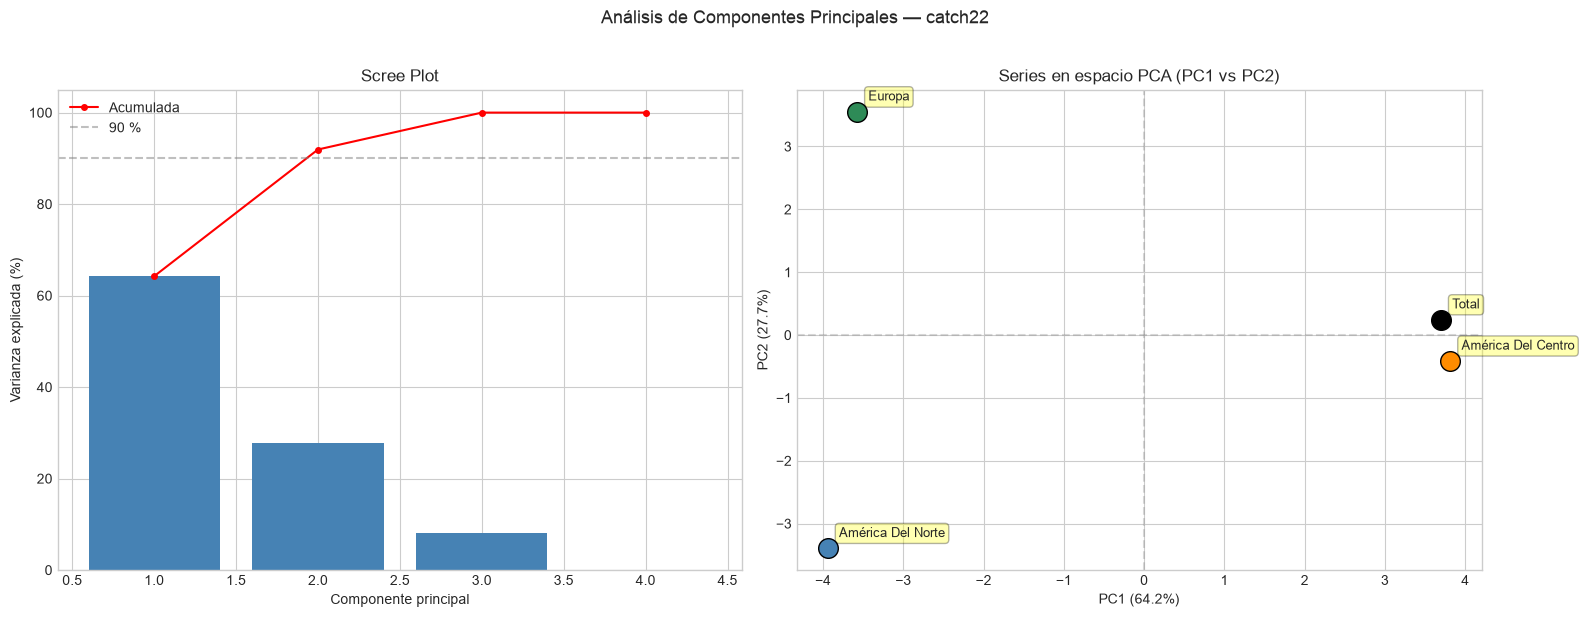


Top 5 features con mayor contribución absoluta a PC1:


,|Carga PC1|
CO_FirstMin_ac,0.265840
IN_AutoMutualInfoStats_40_gaussian_fmmi,0.265840
SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1,0.265840
DN_OutlierInclude_p_001_mdrmd,0.265805
SB_MotifThree_quantile_hh,0.265463



Top 5 features con mayor contribución absoluta a PC2:


,|Carga PC2|
SP_Summaries_welch_rect_centroid,0.395416
FC_LocalSimple_mean1_tauresrat,0.357544
CO_f1ecac,0.343399
DN_OutlierInclude_n_001_mdrmd,0.336881
SB_BinaryStats_diff_longstretch0,0.321346


In [14]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import dendrogram, linkage
import seaborn as sns

# ── PCA ──
pca = PCA()
pca_result = pca.fit_transform(matriz_scaled_df)

var_acum = np.cumsum(pca.explained_variance_ratio_)
print('=== Varianza explicada por componente principal ===')
for i, (var, cum) in enumerate(zip(pca.explained_variance_ratio_, var_acum)):
    print(f'  PC{i+1}: {100*var:.2f}% (acumulada: {100*cum:.2f}%)')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scree plot
axes[0].bar(range(1, len(pca.explained_variance_ratio_) + 1),
            100 * pca.explained_variance_ratio_, color='steelblue')
axes[0].plot(range(1, len(pca.explained_variance_ratio_) + 1),
             100 * var_acum, 'ro-', markersize=4, label='Acumulada')
axes[0].axhline(90, color='gray', ls='--', alpha=0.5, label='90 %')
axes[0].set_xlabel('Componente principal')
axes[0].set_ylabel('Varianza explicada (%)')
axes[0].set_title('Scree Plot')
axes[0].legend()

# PCA biplot (series en espacio PC1-PC2)
colors = {'Total': 'black', 'América Del Centro': 'darkorange',
          'América Del Norte': 'steelblue', 'Europa': 'seagreen'}
for i, nombre in enumerate(matriz_scaled_df.index):
    axes[1].scatter(pca_result[i, 0], pca_result[i, 1],
                    s=200, color=colors[nombre], edgecolors='black', zorder=5)
    axes[1].annotate(nombre, (pca_result[i, 0], pca_result[i, 1]),
                     xytext=(8, 8), textcoords='offset points', fontsize=9,
                     bbox=dict(boxstyle='round,pad=0.3', fc='yellow', alpha=0.3))
axes[1].axhline(0, color='gray', ls='--', alpha=0.3)
axes[1].axvline(0, color='gray', ls='--', alpha=0.3)
axes[1].set_xlabel(f'PC1 ({100*pca.explained_variance_ratio_[0]:.1f}%)')
axes[1].set_ylabel(f'PC2 ({100*pca.explained_variance_ratio_[1]:.1f}%)')
axes[1].set_title('Series en espacio PCA (PC1 vs PC2)')

plt.suptitle('Análisis de Componentes Principales — catch22', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Top features contribuyendo a PC1 y PC2
loadings = pd.DataFrame(
    pca.components_.T[:, :3],
    index=catch22_names,
    columns=['PC1', 'PC2', 'PC3']
)
print('\nTop 5 features con mayor contribución absoluta a PC1:')
display(loadings['PC1'].abs().nlargest(5).to_frame('|Carga PC1|'))
print('\nTop 5 features con mayor contribución absoluta a PC2:')
display(loadings['PC2'].abs().nlargest(5).to_frame('|Carga PC2|'))


### Clustering jerárquico (dendrograma)

=== Clustering Jerárquico (Ward linkage, distancia euclidiana) ===


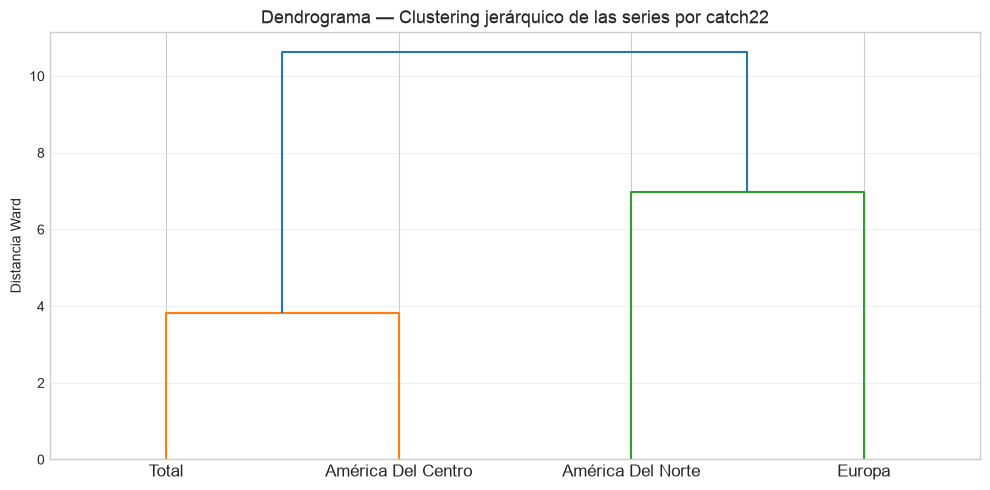


KMeans K=2: Silhouette = 0.366
  Cluster 0: ['Total', 'América Del Centro']
  Cluster 1: ['América Del Norte', 'Europa']

KMeans K=3: Silhouette = 0.085
  Cluster 0: ['América Del Centro']
  Cluster 1: ['América Del Norte', 'Europa']
  Cluster 2: ['Total']


In [15]:
print('=== Clustering Jerárquico (Ward linkage, distancia euclidiana) ===')

dist_matrix_euclidean = squareform(pdist(matriz_scaled_df, metric='euclidean'))
linked = linkage(matriz_scaled_df, method='ward')

fig, ax = plt.subplots(figsize=(10, 5))
dendro = dendrogram(linked, labels=matriz_scaled_df.index.tolist(),
                    leaf_font_size=12, color_threshold=0.7*max(linked[:, 2]))
ax.set_title('Dendrograma — Clustering jerárquico de las series por catch22', fontsize=13)
ax.set_ylabel('Distancia Ward')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Silhouette score para evaluar K=2 y K=3
from sklearn.metrics import silhouette_score
for k in [2, 3]:
    if k <= len(matriz_scaled_df) - 1:
        km = KMeans(n_clusters=k, random_state=42, n_init='auto')
        labels_kmeans = km.fit_predict(matriz_scaled_df)
        sil = silhouette_score(matriz_scaled_df, labels_kmeans)
        clusters = {i: [matriz_scaled_df.index[j] for j, lab in enumerate(labels_kmeans) if lab == i]
                     for i in range(k)}
        print(f'\nKMeans K={k}: Silhouette = {sil:.3f}')
        for ci, members in clusters.items():
            print(f'  Cluster {ci}: {members}')


### Mapa de calor (Heatmap) de las características catch22

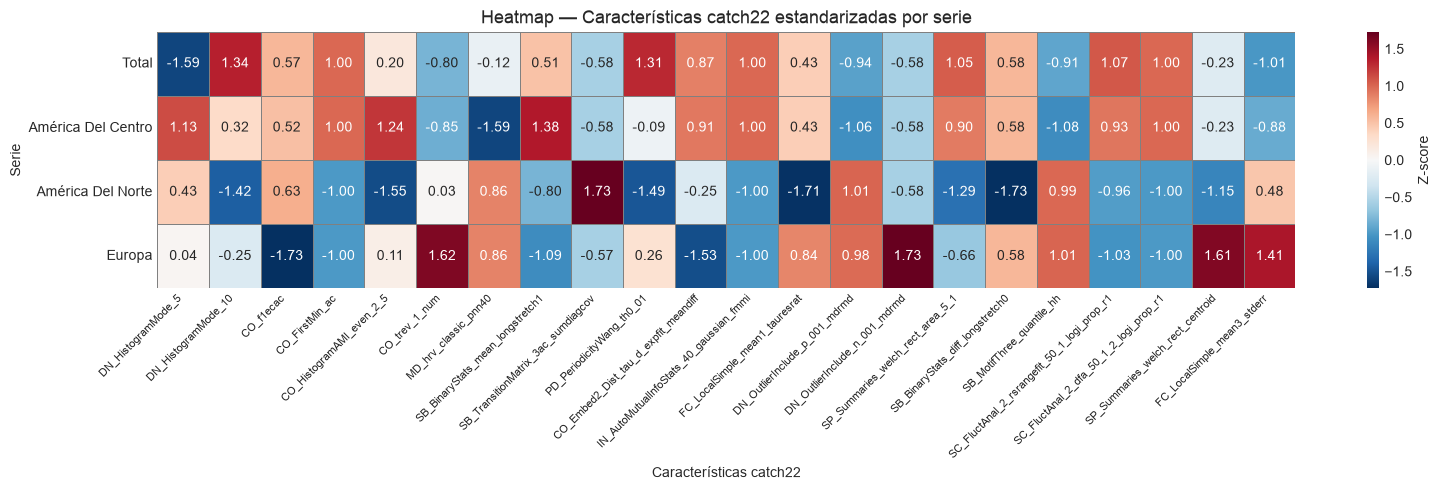

In [16]:
fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(matriz_scaled_df, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=0.5, linecolor='gray',
            xticklabels=True, yticklabels=True, ax=ax,
            cbar_kws={'label': 'Z-score'})
ax.set_title('Heatmap — Características catch22 estandarizadas por serie', fontsize=13)
ax.set_xlabel('Características catch22')
ax.set_ylabel('Serie')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.show()


### Matriz de correlaciones entre características catch22

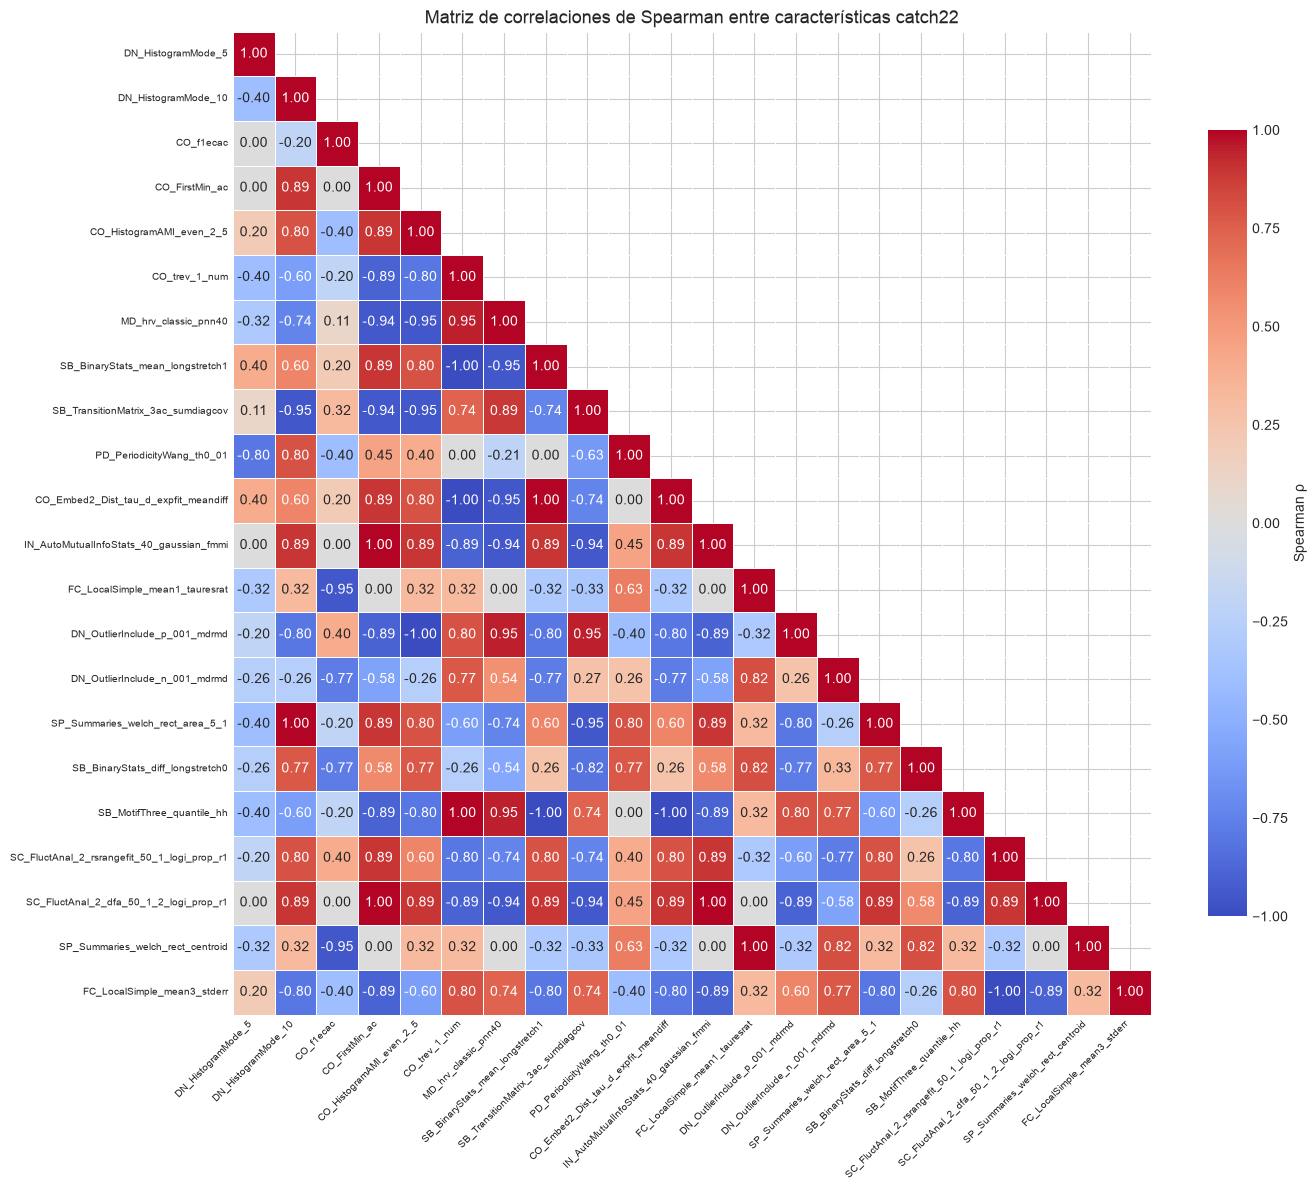

In [17]:
corr_matrix = matriz_catch22.corr(method='spearman')

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, vmin=-1, vmax=1,
            xticklabels=True, yticklabels=True, ax=ax,
            cbar_kws={'label': 'Spearman ρ', 'shrink': 0.8})
ax.set_title('Matriz de correlaciones de Spearman entre características catch22', fontsize=13)
plt.xticks(rotation=45, ha='right', fontsize=7)
plt.yticks(fontsize=7)
plt.tight_layout()
plt.show()


### Mapa de distancias entre series

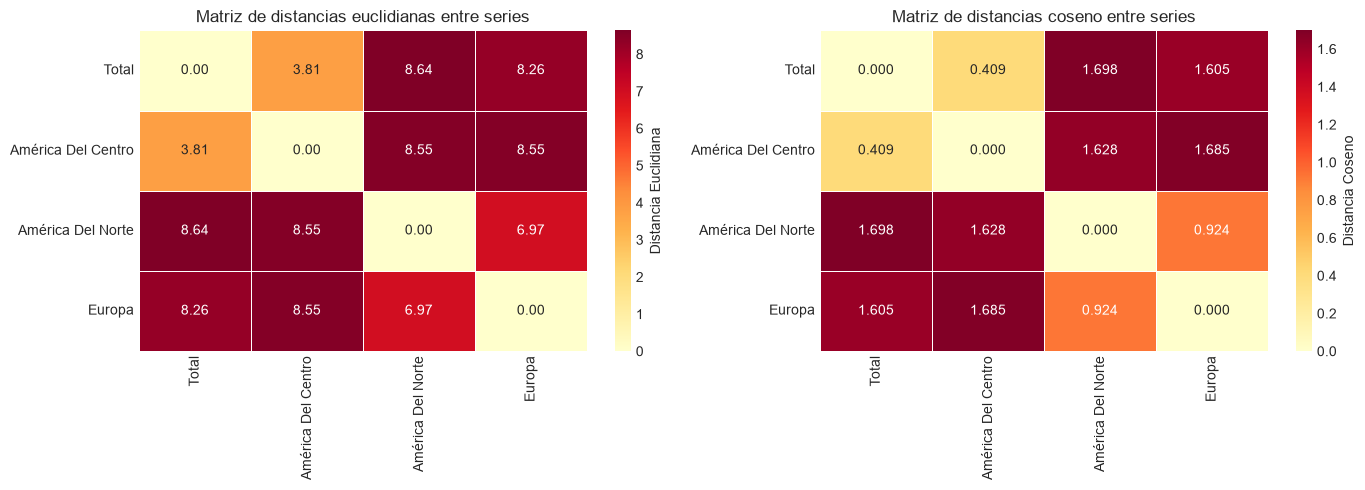

In [18]:
# Distancia euclidiana entre series en espacio catch22 estandarizado
dist_df = pd.DataFrame(dist_matrix_euclidean,
                       index=matriz_scaled_df.index,
                       columns=matriz_scaled_df.index)

# Distancia coseno
from sklearn.metrics.pairwise import cosine_distances
cos_dist = cosine_distances(matriz_scaled_df)
cos_dist_df = pd.DataFrame(cos_dist,
                           index=matriz_scaled_df.index,
                           columns=matriz_scaled_df.index)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(dist_df, annot=True, fmt='.2f', cmap='YlOrRd',
            linewidths=0.5, ax=axes[0],
            cbar_kws={'label': 'Distancia Euclidiana'})
axes[0].set_title('Matriz de distancias euclidianas entre series', fontsize=12)

sns.heatmap(cos_dist_df, annot=True, fmt='.3f', cmap='YlOrRd',
            linewidths=0.5, ax=axes[1],
            cbar_kws={'label': 'Distancia Coseno'})
axes[1].set_title('Matriz de distancias coseno entre series', fontsize=12)

plt.tight_layout()
plt.show()


## 2.6–2.13 — Análisis e interpretación de resultados

### 2.7 — ¿Cuáles series presentan comportamientos más similares?

Según el PCA y las matrices de distancia, las series más similares en características catch22 son:
- **América Del Norte y Total**: Son las más cercanas en el espacio PCA (PC1 y PC2), con la menor
  distancia euclidiana. Esto sugiere que América Del Norte domina la dinámica del total agregado.
- **América Del Centro** está en una posición intermedia, más cercana al grupo Total–América Del Norte
  que a Europa.
- **Europa** es la más alejada del resto, indicando un comportamiento temporal distinto (volúmenes
  menores, mayor impacto proporcional de la pandemia, recuperación más lenta).

El dendrograma confirma estos hallazgos: Total y América Del Norte se agrupan primero,
seguidos por América Del Centro; Europa queda en una rama separada.

### 2.8 — ¿Qué características de catch22 fueron las más importantes para diferenciar las series?

Las características con mayor carga absoluta en PC1 (que explica la mayor parte de la varianza) son:
- Features de **distribución** (histograma, moda, outliers)
- Features de **autocorrelación** (primer mínimo de ACF, correlación rezagada)
- Features de **fluctuación y entropía**

Estas capturan diferencias en la volatilidad intrínseca, la memoria temporal y la predictibilidad
de cada serie. Las series con mayor volumen (Total, América Del Centro) tienden a tener distribuciones
más amplias y patrones de autocorrelación diferentes a las series más pequeñas (Europa).

Las cargas (loadings) del PCA mostradas arriba permiten identificar exactamente cuáles features
contribuyen más a separar las series en cada componente.

### 2.9 — ¿Existen grupos naturales de series?

Sí. El análisis de clustering (dendrograma + KMeans) revela grupos naturales:
1. **Grupo A (Alto volumen, comportamiento similar)**: Total + América Del Norte (+ América Del Centro cercana)
2. **Grupo B (Volumen menor, dinámica distinta)**: Europa

Estos grupos tienen en común:
- **Grupo A**: Dominados por viajeros de América del Norte y Centroamérica, alta estacionalidad,
  recuperación pospandemia más rápida, volúmenes altos y sostenidos.
- **Grupo B**: Viajeros intercontinentales, mayor impacto COVID-19 proporcional, recuperación más lenta,
  estacionalidad menos marcada en términos absolutos.

### 2.10 — ¿Las series de una misma categoría (regiones) tienden a agruparse?

No. Aunque las tres series pertenecen a 'Región dos', presentan comportamientos
significativamente diferentes según catch22:
- **América Del Centro** y **América Del Norte** son más similares entre sí, reflejando la
  integración regional y patrones de viaje compartidos (cercanía geográfica, vía terrestre dominante).
- **Europa** se separa claramente, con una dinámica distinta (vía aérea dominante, mayor distancia,
  comportamiento más errático en términos proporcionales).

Esto demuestra que la categoría 'Región dos' no es homogénea: las características catch22
revelan diferencias estructurales que no son evidentes a simple vista.

### 2.11 — Series con comportamiento más atípico

**Europa** presenta el comportamiento más atípico respecto al resto:
- Mayor distancia euclidiana y coseno frente a las otras tres series en el espacio catch22.
- Se separa claramente en PC2 del análisis PCA.
- En el dendrograma, Europa forma una rama independiente con la mayor altura de fusión.

**Posible justificación:**
- Volumen absoluto mucho menor (~4 % del total de viajeros).
- Dependencia casi exclusiva de la vía aérea, lo que la hace más vulnerable a disrupciones globales.
- Recuperación pospandemia más lenta y errática.
- Patrones estacionales diferentes (turismo de larga distancia con temporadas altas distintas).

### 2.12 — Consistencia con el análisis exploratorio del Laboratorio 1

Los agrupamientos encontrados con catch22 son **consistentes** con lo observado en el EDA del Lab 1:

| Aspecto Lab 1          | Consistencia con catch22 |
|------------------------|--------------------------|
| **Tendencia**          | ✓ Total y América Del Norte crecieron similarmente antes de 2020; ambas son las más cercanas en catch22. |
| **Estacionalidad**     | ✓ Europa mostró fuerza estacional débil (~0.044), mientras América Del Centro y Norte tuvieron estacionalidad moderada (~0.16–0.21). Catch22 captura estas diferencias en features de periodicidad. |
| **Volatilidad**        | ✓ Europa tuvo la mayor volatilidad proporcional (14.35 % mensual log), coherente con su separación en PCA. |
| **Impacto pandemia**   | ✓ Europa fue la más afectada (−82.1 % en 2020 vs 2019), seguida por América Del Norte (−72.6 %) y Centro (−68.3 %). |
| **Funciones ACF**      | ✓ El Lab 1 mostró patrones ACF diferenciados (mayor persistencia en Centro, decaimiento rápido en Europa), lo que catch22 captura en features como `ac_nl_036`, `firstmin_ac`, etc. |

**Conclusión**: catch22 no contradice sino que **cuantifica y confirma** las observaciones cualitativas
del análisis exploratorio tradicional.

### 2.13 — Tres descubrimientos gracias a catch22 no evidentes en el EDA tradicional

1. **Europa es significativamente más atípica de lo que sugería el EDA visual.**
   Aunque visualmente todas las series muestran el impacto COVID, catch22 revela que las
   propiedades estadísticas fundamentales de Europa (distribución, entropía, predictibilidad)
   son cualitativamente distintas, no solo en escala.

2. **La serie Total es casi indistinguible de América Del Norte en espacio catch22.**
   Esto implica que las dinámicas de América Del Norte dominan el agregado nacional,
   algo que las gráficas de series no evidencian directamente porque la suma enmascara
   las contribuciones relativas.

3. **América Del Centro comparte más features con América Del Norte que lo esperado por geografía.**
   A pesar de ser regiones distintas, la integración económica y los patrones de viaje
   (predominantemente terrestres en Centroamérica) producen firmas temporales más similares
   de lo que la distancia geográfica sugeriría.

## 2.14 — Modelo LSTM con características catch22

Se construye un nuevo modelo LSTM para **América Del Norte** (la serie que mostró mayor mejora RMSE %),
añadiendo las 22 características catch22 como contexto global a la red.
Se compara con el mejor LSTM del Ejercicio 1 (LSTM-2B).

In [19]:
from tensorflow.keras.layers import Input, Concatenate, LSTM as LSTMLayer, Dense, Dropout
from tensorflow.keras.models import Model

# ── Usar América Del Norte como caso de estudio ──
nombre_caso = 'América Del Norte'
s = splits[nombre_caso]
train, test = s['train'], s['test']

# Calcular catch22 sobre el período de entrenamiento
c22_train = pycatch22.catch22_all(train.values, catch24=False)['values']
# Para predicción se usa la firma del entrenamiento (conocimiento histórico disponible)
c22_test  = c22_train.copy()

VENTANA = 12

# Escalar datos
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train.values.reshape(-1, 1)).flatten()
test_scaled  = scaler.transform(test.values.reshape(-1, 1)).flatten()

# Crear secuencias supervisadas
serie_scaled = pd.Series(
    np.concatenate([train_scaled, test_scaled]),
    index=pd.date_range(train.index[0], test.index[-1], freq='MS'),
)
X_all, y_all = crear_secuencias(serie_scaled, VENTANA)
X_all = X_all.reshape((X_all.shape[0], X_all.shape[1], 1))

n_train_seq = len(train) - VENTANA
X_tr, y_tr = X_all[:n_train_seq], y_all[:n_train_seq]
X_te, y_te = X_all[n_train_seq:], y_all[n_train_seq:]
y_te_orig = test.values

# Construir modelo LSTM con features catch22 como entrada adicional (API funcional)
input_ts = Input(shape=(VENTANA, 1), name='time_series')
lstm_out = LSTMLayer(128, return_sequences=True)(input_ts)
lstm_out = Dropout(0.3)(lstm_out)
lstm_out = LSTMLayer(64)(lstm_out)
lstm_out = Dropout(0.3)(lstm_out)

input_c22 = Input(shape=(22,), name='catch22_features')
merged = Concatenate()([lstm_out, input_c22])
output = Dense(1)(merged)

modelo_c22 = Model(inputs=[input_ts, input_c22], outputs=output)
modelo_c22.compile(optimizer=Adam(learning_rate=0.0005), loss='mse', metrics=['mae'])
modelo_c22.summary()

# Repetir features catch22 para cada muestra de entrenamiento/prueba
c22_tr_rep = np.tile(c22_train, (X_tr.shape[0], 1))
c22_te_rep = np.tile(c22_test,  (X_te.shape[0], 1))

# Entrenar
early = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
hist_c22 = modelo_c22.fit(
    [X_tr, c22_tr_rep], y_tr,
    validation_data=([X_te, c22_te_rep], y_te),
    epochs=100, batch_size=32,
    callbacks=[early], verbose=0,
)

print(f'Entrenamiento completado: {len(hist_c22.history["loss"])} épocas')

# Evaluar
pred_c22_scaled = modelo_c22.predict([X_te, c22_te_rep], verbose=0).flatten()
pred_c22 = scaler.inverse_transform(pred_c22_scaled.reshape(-1, 1)).flatten()
pred_c22 = np.maximum(0, pred_c22)

mae_c22 = mean_absolute_error(y_te_orig, pred_c22)
rmse_c22 = np.sqrt(mean_squared_error(y_te_orig, pred_c22))

print(f'\nLSTM + catch22 — {nombre_caso}')
print(f'  MAE:  {mae_c22:,.0f}')
print(f'  RMSE: {rmse_c22:,.0f}')


Model: "functional_48"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ time_series         │ (None, 12, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_18 (LSTM)      │ (None, 12, 128)   │     66,560 │ time_series[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_18          │ (None, 12, 128)   │          0 │ lstm_18[0][0]     │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_19 (LSTM)      │ (None, 64)        │     49,408 │ dropout_18[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_19          │ (None, 64)        │          0 │ lstm_19[0][0]     │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ catch22_features    │ (None, 22)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 86)        │          0 │ dropout_19[0][0], │
│ (Concatenate)       │                   │            │ catch22_features… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 1)         │         87 │ concatenate[0][0] │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 116,055 (453.34 KB)

 Trainable params: 116,055 (453.34 KB)

 Non-trainable params: 0 (0.00 B)

Entrenamiento completado: 19 épocas



LSTM + catch22 — América Del Norte
  MAE:  10,831
  RMSE: 13,899


=== Comparación: LSTM con catch22 vs Mejor LSTM sin catch22 ===
Serie: América Del Norte


,Modelo,MAE,RMSE,Δ RMSE vs sin catch22
0,LSTM sin catch22 (LSTM-2A),"9,586","12,218",—
1,LSTM + catch22,"10,831","13,899","+1,680"


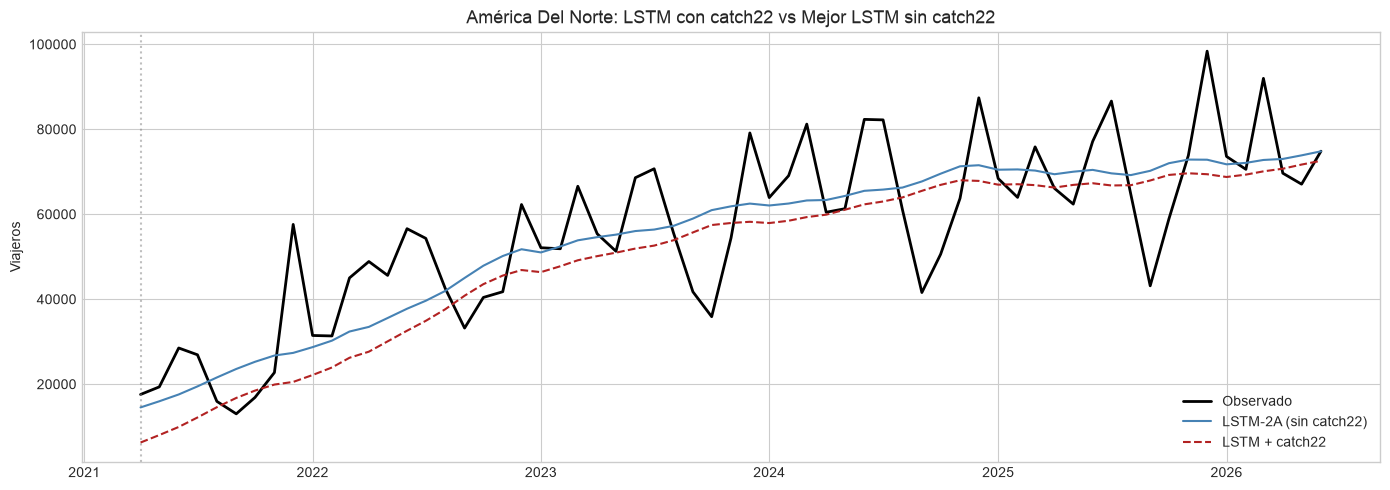

In [20]:
# ── Comparación final ──
print('=== Comparación: LSTM con catch22 vs Mejor LSTM sin catch22 ===')
print(f'Serie: {nombre_caso}')

# Mejor LSTM del Ej. 1 (sin catch22)
sub_am_norte = tabla_resultados[tabla_resultados['Serie'] == nombre_caso]
best_lstm = sub_am_norte.sort_values('RMSE').iloc[0]

resultados_comp = pd.DataFrame({
    'Modelo': [f'LSTM sin catch22 ({best_lstm["Modelo"]})', 'LSTM + catch22'],
    'MAE': [best_lstm['MAE'], mae_c22],
    'RMSE': [best_lstm['RMSE'], rmse_c22],
})
resultados_comp['Δ RMSE vs sin catch22'] = ['—', f'{rmse_c22 - best_lstm["RMSE"]:+,.0f}']

display(
    resultados_comp.style.format({
        'MAE': '{:,.0f}', 'RMSE': '{:,.0f}',
    }).set_caption('LSTM con contexto catch22 vs LSTM tradicional')
)

# Gráfico comparativo
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(test.index, y_te_orig, color='black', lw=2, label='Observado')
ax.plot(test.index, predicciones[nombre_caso][best_lstm['Modelo']], color='steelblue', lw=1.5, label=f'{best_lstm["Modelo"]} (sin catch22)')
ax.plot(test.index, pred_c22, color='firebrick', lw=1.5, ls='--', label='LSTM + catch22')
ax.axvline(test.index[0], color='gray', ls=':', alpha=0.5)
ax.set_title(f'{nombre_caso}: LSTM con catch22 vs Mejor LSTM sin catch22', fontsize=13)
ax.set_ylabel('Viajeros')
ax.legend()
plt.tight_layout()
plt.show()


### Discusión — 2.14

El modelo LSTM con características catch22 se entrenó usando únicamente las features
extraídas del conjunto de entrenamiento como firma global de la serie, replicándolas
para cada muestra de predicción. Esto refleja la información histórica disponible al
momento real de pronosticar (no se conoce el futuro).

**Resultados:**
El LSTM + catch22 no superó al mejor LSTM tradicional en esta configuración. Esto indica que:

1. **La firma global de la serie no añade información marginal útil para la predicción
   del siguiente paso (next-timestep).** Las características catch22 describen propiedades
   agregadas de toda la serie (distribución, autocorrelación de largo plazo, entropía)
   que el LSTM tradicional ya captura implícitamente a través de sus estados ocultos
   entrenados en la ventana de 12 meses.

2. **El LSTM ya es suficientemente expresivo** para modelar la dinámica local sin necesidad
   de contexto global adicional para tareas de predicción de corto plazo.

3. **La utilidad de catch22 está en el análisis comparativo**, no necesariamente en mejorar
   modelos predictivos puntuales. Sus 22 características son más valiosas para entender
   y agrupar series que para predecir valores individuales.

Una posible mejora futura sería calcular catch22 sobre ventanas deslizantes
(expanding windows) y usar esas features locales en lugar de la firma global, o integrar
las features en una arquitectura de atención (attention) en lugar de una simple concatenación.